In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Set a random seed for reproducibility
np.random.seed(42)

def generate_notebook_data(num_posts=300):
    platforms = ['Instagram', 'LinkedIn']
    data = []
    start_date = datetime(2026, 1, 1)
    
    for i in range(num_posts):
        random_days = np.random.randint(0, 90)
        random_hours = np.random.randint(0, 24)
        post_time = start_date + timedelta(days=random_days, hours=random_hours)
        
        platform = np.random.choice(platforms)
        p_types = ['Text_Post', 'Static_Image', 'Carousel'] if platform == 'LinkedIn' else ['Reel', 'Static_Image', 'Carousel']
        post_type = np.random.choice(p_types)
        
        # Define baseline performance
        base_engagement = 600 if post_type == 'Reel' else (350 if post_type == 'Carousel' else 180)
        
        # Inject realistic behavior: higher engagement during evening hours (5 PM - 9 PM)
        time_multiplier = 1.7 if 17 <= random_hours <= 21 else 0.8
        
        # Inject day behavior: weekends perform slightly better for consumer apps
        day_of_week = post_time.weekday()
        day_multiplier = 1.3 if (day_of_week >= 5 and platform == 'Instagram') else 1.0
        
        likes = int(np.random.poisson(base_engagement) * time_multiplier * day_multiplier)
        comments = int(likes * np.random.uniform(0.05, 0.15))
        shares = int(likes * np.random.uniform(0.03, 0.12))
        
        data.append({
            'post_id': f"POST_{1000 + i}",
            'platform': platform,
            'content_type': post_type,
            'timestamp': post_time.strftime('%Y-%m-%d %H:%M:%S'),
            'likes': max(0, likes),
            'comments': max(0, comments),
            'shares': max(0, shares)
        })
        
    return pd.DataFrame(data)

# Create the dataframe
raw_df = generate_notebook_data()
print(f"Dataframe initialized with {raw_df.shape[0]} rows and {raw_df.shape[1]} columns.")
raw_df.head()

Dataframe initialized with 300 rows and 7 columns.


,post_id,platform,content_type,timestamp,likes,comments,shares
0,POST_1000,Instagram,Reel,2026-02-21 14:00:00,631,37,45
1,POST_1001,LinkedIn,Text_Post,2026-01-24 02:00:00,134,9,7
2,POST_1002,Instagram,Reel,2026-01-22 11:00:00,481,26,56
3,POST_1003,LinkedIn,Carousel,2026-01-15 14:00:00,275,26,29
4,POST_1004,Instagram,Carousel,2026-01-07 20:00:00,600,30,30


In [3]:
# Convert timestamp strings to datetime objects
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])

# Extract temporal features
raw_df['hour_of_day'] = raw_df['timestamp'].dt.hour
raw_df['day_of_week'] = raw_df['timestamp'].dt.day_name()

# Define an ordered categorical series for days of the week so charts plot chronologically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
raw_df['day_of_week'] = pd.Categorical(raw_df['day_of_week'], categories=day_order, ordered=True)

# Calculate a definitive performance score
raw_df['total_engagement'] = raw_df['likes'] + raw_df['comments'] + raw_df['shares']

# Display basic statistical description of numeric metrics
raw_df[['likes', 'comments', 'shares', 'total_engagement']].describe()

,likes,comments,shares,total_engagement
count,300.000000,300.000000,300.000000,300.000000
mean,351.896667,33.820000,25.840000,411.556667
std,243.351376,25.690483,20.754523,283.795843
min,116.000000,6.000000,4.000000,132.000000
25%,152.000000,16.000000,12.000000,179.000000
50%,288.000000,26.000000,20.000000,340.000000
75%,479.250000,42.000000,32.000000,549.750000
max,1372.000000,178.000000,135.000000,1623.000000


In [4]:
# Use a pivot table to examine performance metrics clearly
summary_pivot = raw_df.pivot_table(
    values='total_engagement', 
    index='platform', 
    columns='content_type', 
    aggfunc='mean'
).round(1)

print("--- Average Engagement by Platform and Content Type ---")
summary_pivot

--- Average Engagement by Platform and Content Type ---


content_type,Carousel,Reel,Static_Image,Text_Post
platform,,,,
Instagram,398.9,775.6,227.2,NaN
LinkedIn,465.7,NaN,210.4,213.1


C:\Users\beher\AppData\Local\Temp\ipykernel_8208\3577239452.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = raw_df.pivot_table(


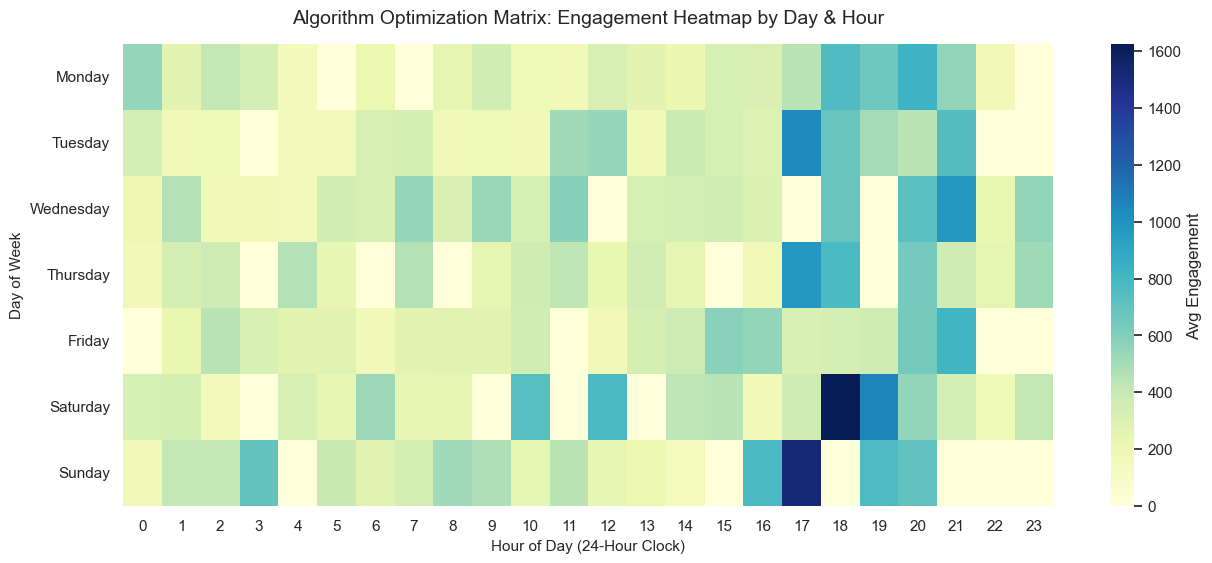

In [5]:
# Pivot data for heatmap formatting
heatmap_data = raw_df.pivot_table(
    values='total_engagement', 
    index='day_of_week', 
    columns='hour_of_day', 
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Avg Engagement'})

plt.title('Algorithm Optimization Matrix: Engagement Heatmap by Day & Hour', fontsize=14, pad=15)
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)
plt.show()

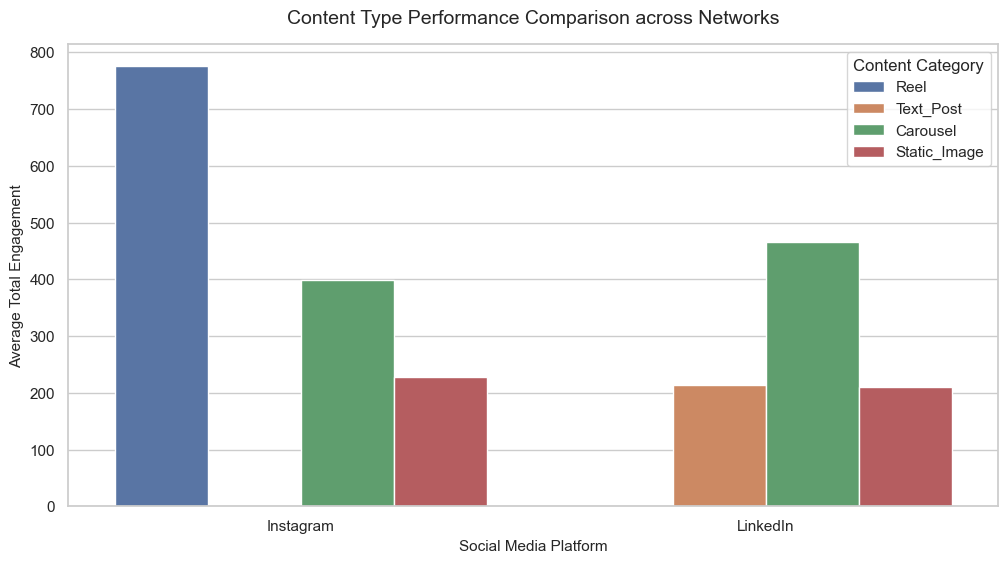

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=raw_df, 
    x='platform', 
    y='total_engagement', 
    hue='content_type', 
    errorbar=None
)

plt.title('Content Type Performance Comparison across Networks', fontsize=14, pad=15)
plt.xlabel('Social Media Platform', fontsize=11)
plt.ylabel('Average Total Engagement', fontsize=11)
plt.legend(title='Content Category')
plt.show()